In [4]:
%load_ext autoreload
%autoreload 2
%reload_ext autoreload

import nest_asyncio
nest_asyncio.apply()

import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "vscode"            

import matplotlib.pyplot as plt
import matplotlib.pylab as pylab
import matplotlib.dates as mdates
plt.style.use('seaborn-v0_8-dark')
params = {'legend.fontsize': 'x-large',
        'figure.figsize': (16, 9),
        'axes.labelsize': 'x-large',
        'axes.titlesize':'x-large',
        'xtick.labelsize':'x-large',
        'ytick.labelsize':'x-large'}
pylab.rcParams.update(params)

import pandas as pd
import numpy as np
import QuantLib as ql
import rateslib as rl

import datetime
import pytz
NY_tz = pytz.timezone("America/New_York") 
CHI_tz = pytz.timezone("America/Chicago") 
UTC_tz = pytz.timezone("UTC")

import warnings
warnings.filterwarnings(
    "ignore",
    category=UserWarning,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
cache_path = r"C:\Users\chris\clee\project-oasis\private\sdranalytics\.cache"
start = NY_tz.localize(datetime.datetime(2025, 12, 29, 7, 0))
end = NY_tz.localize(datetime.datetime(2025, 12, 29, 17, 30))

In [ ]:
# from SDRUtils.products import USD_SOFR_SwapProduct

# product = USD_SOFR_SwapProduct()
# df = product.build_classification_dataframe(start=start, end=end, cache_path=cache_path)

# df

In [13]:
from MDP.IRSwaps.BARCHART_STIRF.rl import BARCHART_STIRF_CURVE

bcsfc = BARCHART_STIRF_CURVE()

In [14]:
ts = pytz.timezone("America/Chicago").localize(datetime.datetime(2025, 12, 31, 16, 0)) 
c, s = bcsfc.build_curve(curve_name="USD-SOFR-1D-Q8", timestamp=ts)

SUCCESS: `conv_tol` reached after 4 iterations (levenberg_marquardt), `f_val`: 0.06767735238580355, `time`: 0.0220s


(<Figure size 1600x900 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x21a1edb3c50>])

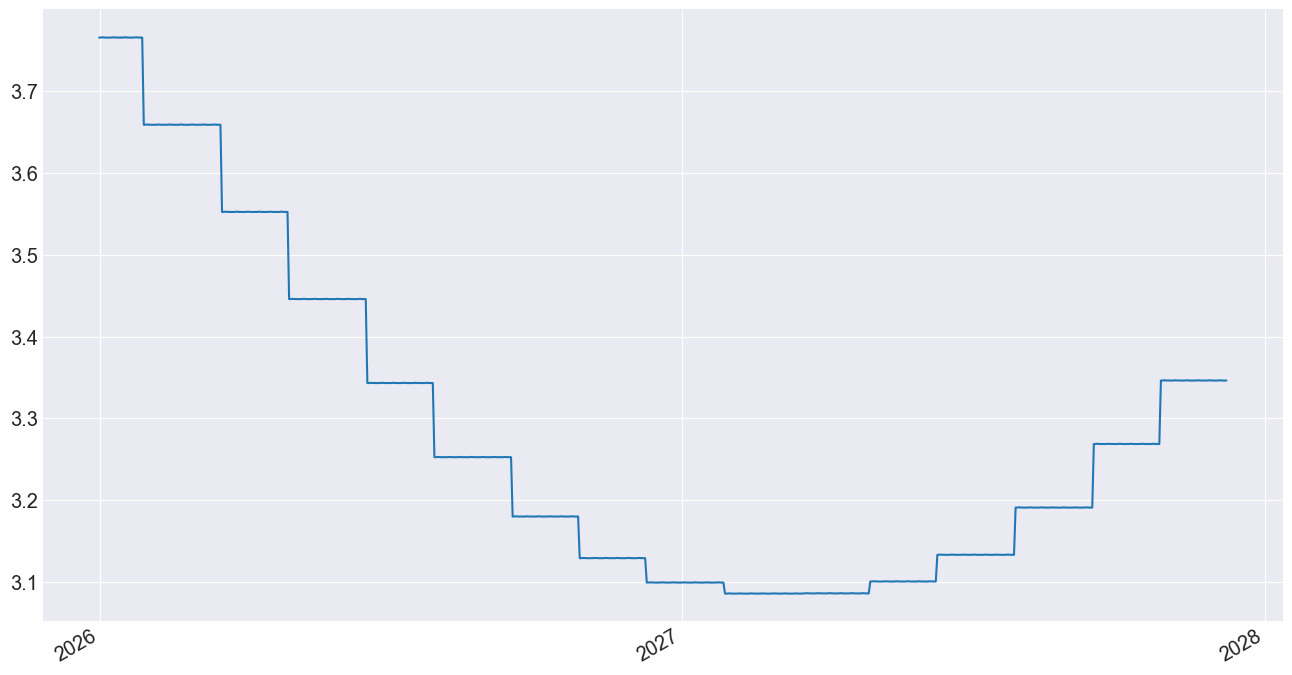

In [15]:
c.plot("1d")

(<Figure size 1600x900 with 1 Axes>,
 <Axes: >,
 [<matplotlib.lines.Line2D at 0x21a22c55f90>])

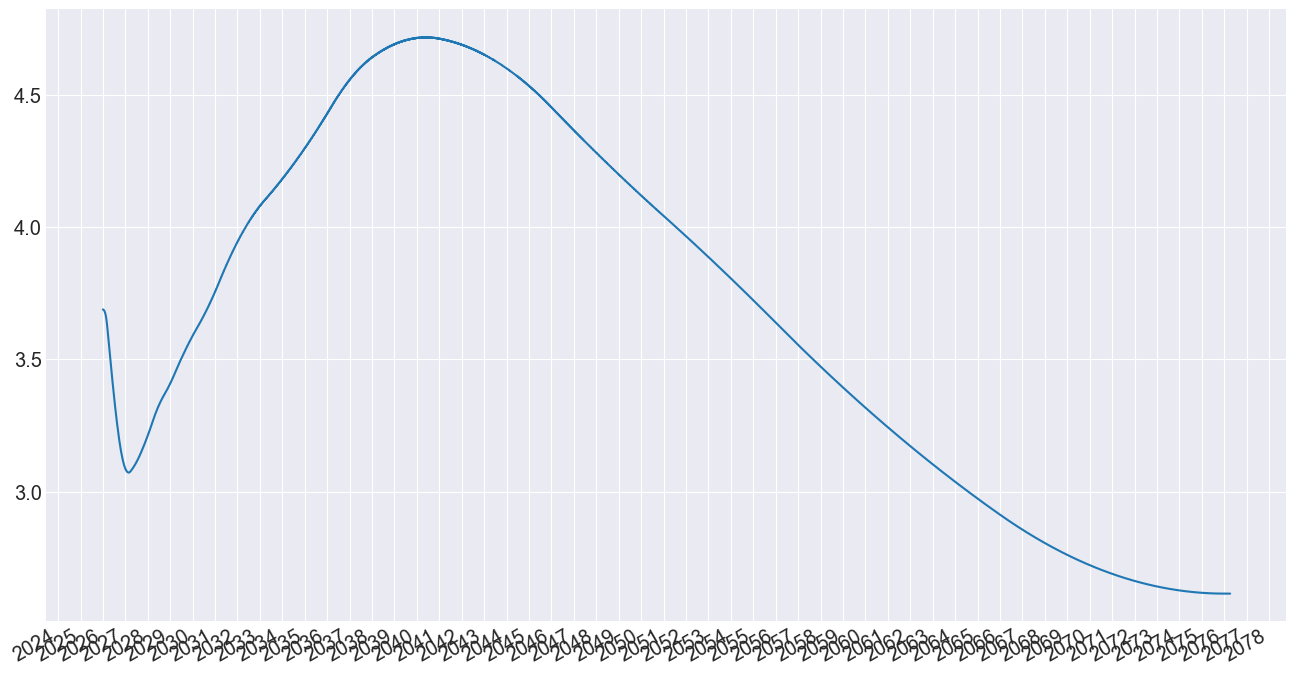

In [ ]:
from MDP.IRSwaps.IRSwapsMDP import IRSwapsMDP

swaps_mdp = IRSwapsMDP(source="ERIS_EOD_LIVE-RL_BASIC-NOJUMPS")
curve_handle = swaps_mdp.get_pricer(dict(curve_name="USD-SOFR-1D", timestamp=datetime.date(2025, 12, 31)))

curve_handle
curve_handle.handle().plot("1d")

In [33]:
from MDP.STIRFutures.STIRFutureMDP import STIRFutureMDP


pricers = STIRFutureMDP(source="BARCHART_TOS_LIVE_STIRF-RL").get_data(
    {
        "symbols": [
            "SERCM2",
        ],
        "timestamp": pytz.timezone("America/Chicago").localize(datetime.datetime(2025, 12, 31, 16, 0)),
    }
)
pricers

{'SERCM2': [RLSTIRFuturePricer(_curve='USD-SOFR-1D', _rl_stirf_id='SR1F26', _reference_date=datetime.date(2025, 12, 31), _effective_date=datetime.date(2026, 1, 2), _maturity_date=datetime.date(2026, 2, 2), _price=96.315, _rate=3.6850000000000023, _contracts=1, _notional=1000000, _meta_data={'symbol': 'SR1F26', 'price': 96.315, 'timestamp': '2025-12-31T15:59:00-06:00', 'schema': 1})]}